# Notebook 04 — Demand Forecasting Model

**Input:** `data/processed/daily_timeseries.csv` (731 days × 18 cols)  
**Goal:** Forecast daily covers using rolling averages (baseline) and Prophet (advanced)  
**Sections:**
- Phase A — Rolling Moving Averages (MA7, MA30)
- Phase B — Prophet Model (with external regressors)


In [1]:
import sys
from pathlib import Path

# Auto-detect project root and add both root and src/ to path
_project_root = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src').exists())
for _p in [str(_project_root), str(_project_root / 'src')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import src.utils_forecast as ut_f

print("Libraries loaded.")


/Applications/anaconda3/envs/horeca_forecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Libraries loaded.


In [2]:
# Load main timeseries (output of Notebook 03)
df = pd.read_csv(
    _project_root / 'data/processed/daily_timeseries.csv',
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

# Cast boolean columns (read as object from CSV in some envs)
bool_cols = ['is_weekend', 'is_holiday', 'is_ponte', 'is_high_season', 'is_bad_weather']
for col in bool_cols:
    df[col] = df[col].astype(bool)

print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols")
print(f"Range: {df['date'].min().date()} → {df['date'].max().date()}")
df[['date', 'covers', 'revenue', 'avg_check']].head(3)


Loaded: 731 rows × 18 cols
Range: 2023-01-01 → 2024-12-31


,date,covers,revenue,avg_check
0,2023-01-01,46.0,1653.23,35.94
1,2023-01-02,42.0,1161.42,27.65
2,2023-01-03,52.0,1523.81,29.30


---
## Phase A — Rolling Moving Averages

Baseline reference: MA7 (weekly smoothing) and MA30 (monthly trend).  
These are not predictive models — they serve as visual anchors to understand the underlying demand signal before applying Prophet.


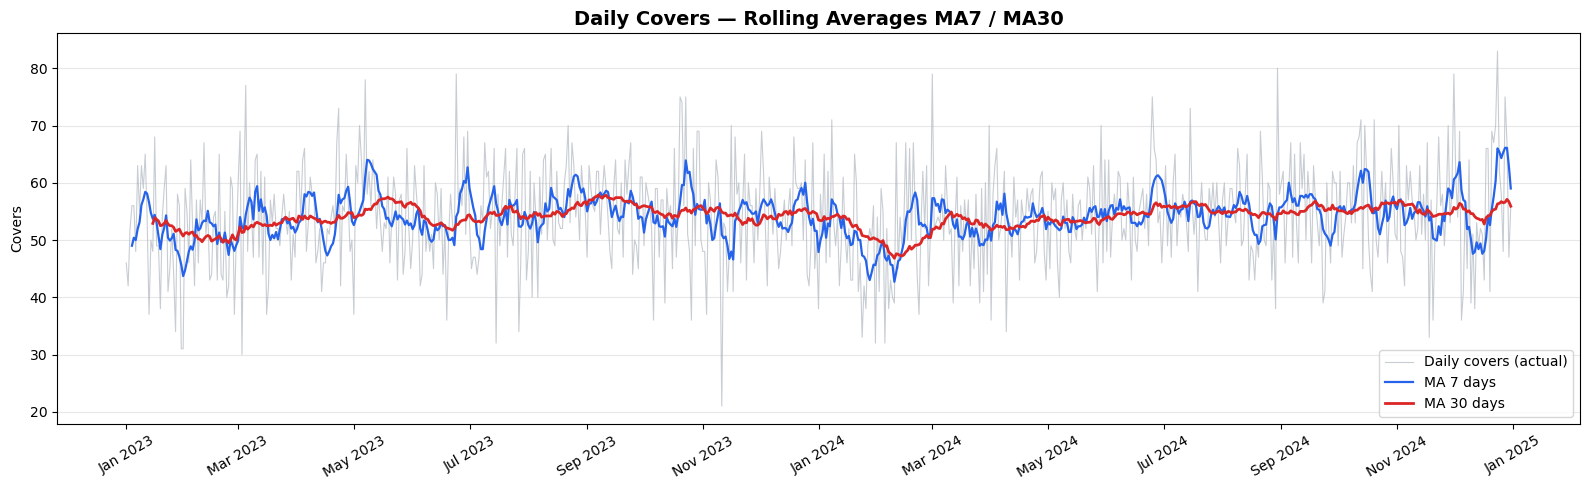


MA7  — mean: 54.1  |  min: 42.7  |  max: 66.1
MA30 — mean: 54.1  |  min: 46.8  |  max: 57.9


In [3]:
# Compute rolling averages (min_periods avoids NaN at the start of the series)
df['ma7']  = df['covers'].rolling(window=7,  min_periods=4).mean().round(1)
df['ma30'] = df['covers'].rolling(window=30, min_periods=15).mean().round(1)

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['date'], df['covers'], color='#b0b8c1', linewidth=0.8,
        alpha=0.7, label='Daily covers (actual)')
ax.plot(df['date'], df['ma7'],  color='#2563eb', linewidth=1.6, label='MA 7 days')
ax.plot(df['date'], df['ma30'], color='#dc2626', linewidth=2.0, label='MA 30 days')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
ax.set_title('Daily Covers — Rolling Averages MA7 / MA30', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMA7  — mean: {df['ma7'].mean():.1f}  |  min: {df['ma7'].min():.1f}  |  max: {df['ma7'].max():.1f}")
print(f"MA30 — mean: {df['ma30'].mean():.1f}  |  min: {df['ma30'].min():.1f}  |  max: {df['ma30'].max():.1f}")


---
## Phase B — Prophet Forecasting Model

**Train/test split:** last 90 days as test set (Oct 3 – Dec 31 2024), rest as train.  
This gives a full Q4 out-of-sample evaluation, including two holiday peaks (Christmas, New Year).

**External regressors added:**
| Regressor | Type | Rationale |
|-----------|------|-----------|
| `is_holiday` | binary | Public holiday demand shift |
| `is_ponte` | binary | Bridge day effect |
| `is_weekend` | binary | Structural weekend pattern |
| `avg_temp` | continuous | Temperature comfort effect |
| `rain_mm` | continuous | Rain deterrence |
| `is_bad_weather` | binary | Extreme weather flag |
| `event_magnitude` | ordinal 0–3 | Local event pull |
| `event_radius_km` | continuous | Event proximity weight |

`is_high_season` excluded: redundant with Prophet's built-in yearly seasonality.


In [4]:
# --- Prophet data prep ---
# Prophet requires columns named 'ds' (date) and 'y' (target)
REGRESSORS = [
    'is_holiday', 'is_ponte',
    'avg_temp', 'rain_mm',
    'event_magnitude', 'event_radius_km'
]

prophet_df = df[['date', 'covers'] + REGRESSORS].copy()
prophet_df = prophet_df.rename(columns={'date': 'ds', 'covers': 'y'})

# Cast booleans to int (Prophet works with numeric regressors)
for col in ['is_holiday', 'is_ponte']:
    prophet_df[col] = prophet_df[col].astype(int)

# --- Train / Test split: last 90 days as test ---
TEST_DAYS = 90
split_date = prophet_df['ds'].max() - pd.Timedelta(days=TEST_DAYS - 1)

train = prophet_df[prophet_df['ds'] < split_date].copy()
test  = prophet_df[prophet_df['ds'] >= split_date].copy()

print(f"Train: {len(train)} days  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test:  {len(test)} days   ({test['ds'].min().date()} → {test['ds'].max().date()})")


Train: 641 days  (2023-01-01 → 2024-10-02)
Test:  90 days   (2024-10-03 → 2024-12-31)


In [5]:
# --- Build and fit Prophet model ---
model = Prophet(
    changepoint_prior_scale=0.1,
    seasonality_mode='additive',
    holidays_prior_scale=10,
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

# Add all external regressors
for reg in REGRESSORS:
    model.add_regressor(reg)

model.fit(train)
print("Model fitted successfully.")


11:29:22 - cmdstanpy - INFO - Chain [1] start processing
11:29:23 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.


**Note:** This model is a Proof of Concept trained on 2023-2024 synthetic data. For production use, the model must be retrained weekly with updated data. Forecasting 16 months ahead without 2025 data introduces trend extrapolation risk.


In [6]:
# --- Predict on test set ---
forecast = model.predict(test)

# Merge actual vs predicted
results = test[['ds', 'y']].copy().reset_index(drop=True)
results['yhat']       = forecast['yhat'].values.round(1)
results['yhat_lower'] = forecast['yhat_lower'].values.round(1)
results['yhat_upper'] = forecast['yhat_upper'].values.round(1)
results['error']      = (results['y'] - results['yhat']).round(1)

# --- Metrics: RMSE and MAPE ---
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mape = (np.abs(results['error']) / results['y']).mean() * 100

print("=" * 40)
print(f"  RMSE : {rmse:.2f} covers")
print(f"  MAPE : {mape:.2f}%")
print("=" * 40)

results.head(10)


  RMSE : 10.07 covers
  MAPE : 14.57%


,ds,y,yhat,yhat_lower,yhat_upper,error
0,2024-10-03,47.0,50.7,40.5,61.8,-3.7
1,2024-10-04,51.0,51.3,40.8,62.3,-0.3
2,2024-10-05,54.0,53.9,43.0,64.5,0.1
3,2024-10-06,60.0,54.8,44.6,65.4,5.2
4,2024-10-07,60.0,52.1,42.1,62.8,7.9
5,2024-10-08,53.0,52.0,41.8,62.4,1.0
6,2024-10-09,63.0,55.3,44.8,65.5,7.7
7,2024-10-10,53.0,54.0,43.7,64.5,-1.0
8,2024-10-11,67.0,54.9,43.8,65.1,12.1
9,2024-10-12,68.0,56.1,45.1,66.3,11.9


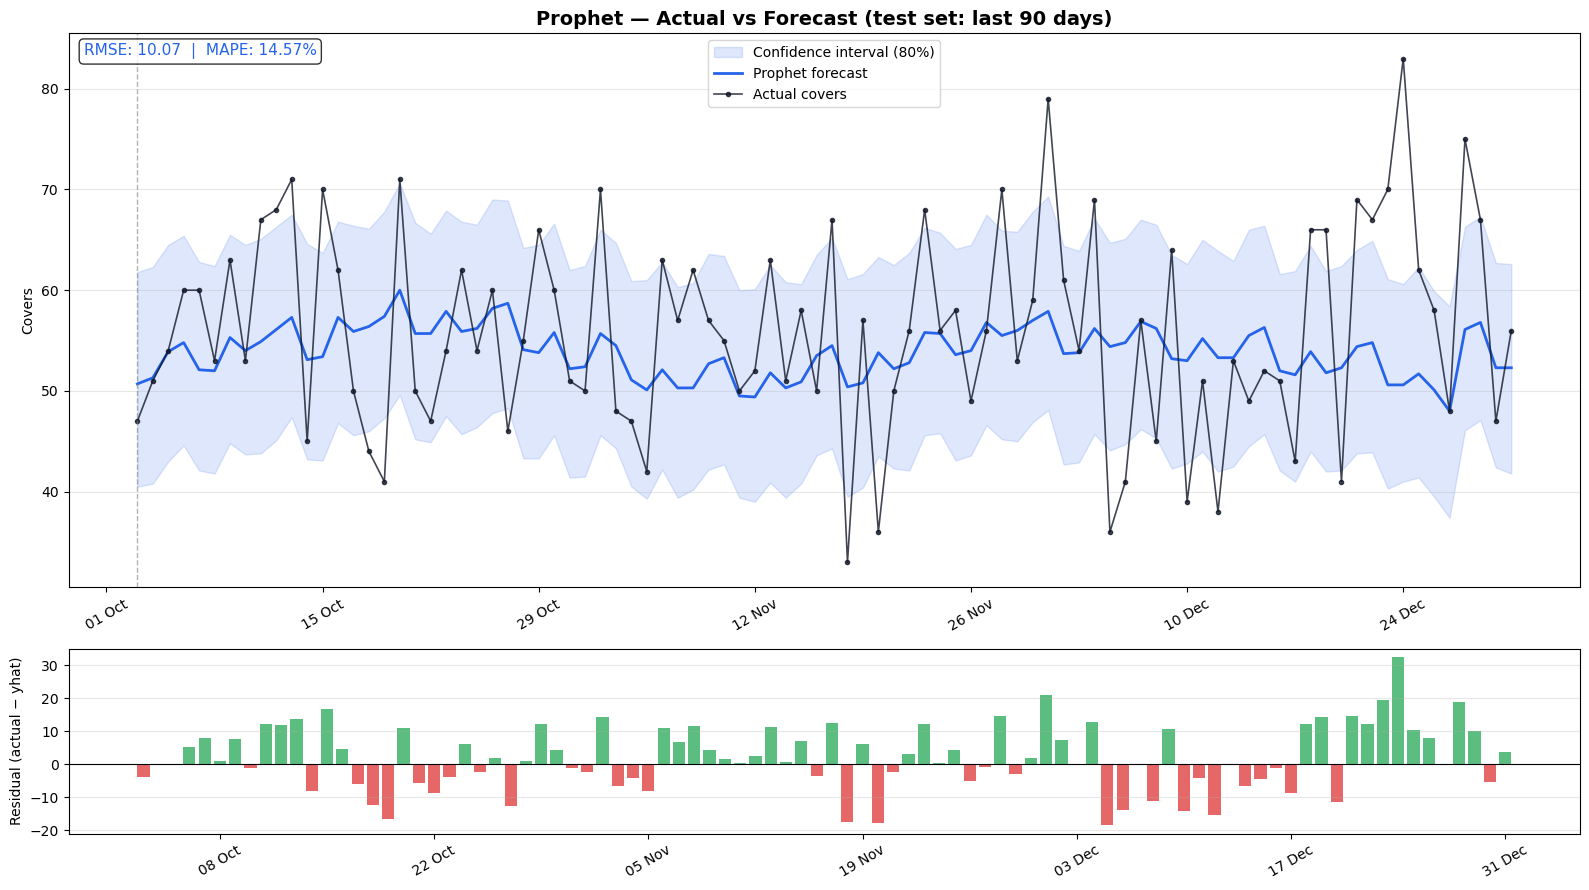

In [7]:
# --- Plot: Actual vs Predicted on test set ---
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={'height_ratios': [3, 1]})

# Top panel: actual vs forecast with confidence interval
ax = axes[0]
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(results['ds'], results['yhat'], color='#2563eb', linewidth=2.0,
        label='Prophet forecast')
ax.plot(results['ds'], results['y'], color='#111827', linewidth=1.2,
        marker='o', markersize=3, alpha=0.8, label='Actual covers')

ax.axvline(results['ds'].iloc[0], color='gray', linestyle='--', linewidth=1.0, alpha=0.6)
ax.set_title('Prophet — Actual vs Forecast (test set: last 90 days)', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers')
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax.get_xticklabels(), rotation=30)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add RMSE / MAPE annotation
ax.annotate(f'RMSE: {rmse:.2f}  |  MAPE: {mape:.2f}%',
            xy=(0.01, 0.96), xycoords='axes fraction',
            fontsize=11, color='#2563eb',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# Bottom panel: residuals (actual - predicted)
ax2 = axes[1]
colors = ['#dc2626' if e < 0 else '#16a34a' for e in results['error']]
ax2.bar(results['ds'], results['error'], color=colors, alpha=0.7, width=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Residual (actual − yhat)')
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax2.get_xticklabels(), rotation=30)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


---
## Phase C — Peak Analysis: Covers vs MA7 Correlation with Weather / Events

Identify the top 10 positive and top 10 negative peaks in daily covers  
relative to the MA7 rolling average. Goal: understand what external signals  
(weather, events) drive demand spikes and drops.


In [8]:
# Phase C — Peak Analysis
# ma7 already computed in Phase A; drop rows where ma7 is NaN (first few days)
peak_cols = ['date', 'covers', 'ma7', 'is_bad_weather',
             'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']

peaks_df = df[peak_cols].dropna(subset=['ma7']).copy()
peaks_df['delta'] = (peaks_df['covers'] - peaks_df['ma7']).round(1)

# Top 10 positive peaks (covers well above MA7)
top_pos = peaks_df.nlargest(10, 'delta')[
    ['date', 'covers', 'ma7', 'delta',
     'is_bad_weather', 'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']
].reset_index(drop=True)

# Top 10 negative peaks (covers well below MA7)
top_neg = peaks_df.nsmallest(10, 'delta')[
    ['date', 'covers', 'ma7', 'delta',
     'is_bad_weather', 'avg_temp', 'rain_mm', 'event_name', 'event_magnitude']
].sort_values('delta').reset_index(drop=True)

pd.set_option('display.max_colwidth', 35)
pd.set_option('display.float_format', '{:.1f}'.format)

print("=" * 70)
print("TOP 10 POSITIVE PEAKS  (covers >> MA7)")
print("=" * 70)
display(top_pos)

print()
print("=" * 70)
print("TOP 10 NEGATIVE PEAKS  (covers << MA7)")
print("=" * 70)
display(top_neg)


TOP 10 POSITIVE PEAKS  (covers >> MA7)


,date,covers,ma7,delta,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2024-08-30,80.0,54.4,25.6,False,26.8,0.0,GP Italia F1,3
1,2023-06-24,79.0,54.1,24.9,False,24.8,0.0,NaN,0
2,2023-03-05,77.0,54.4,22.6,False,8.8,0.0,NaN,0
3,2024-02-11,67.0,44.4,22.6,False,8.9,6.9,NaN,0
4,2023-11-16,70.0,48.0,22.0,False,10.6,0.0,NaN,0
5,2024-03-01,79.0,57.3,21.7,True,9.2,23.9,NaN,0
6,2024-08-21,69.0,49.9,19.1,False,26.7,0.0,NaN,0
7,2024-12-01,79.0,60.6,18.4,False,7.5,0.0,Mercatini di Natale Como,2
8,2023-10-20,75.0,56.7,18.3,True,15.0,67.8,NaN,0
9,2024-03-31,70.0,51.7,18.3,True,11.0,34.4,Pasqua e Pasquetta,2



TOP 10 NEGATIVE PEAKS  (covers << MA7)


,date,covers,ma7,delta,is_bad_weather,avg_temp,rain_mm,event_name,event_magnitude
0,2023-11-11,21.0,50.9,-29.9,False,10.2,0.0,EICMA 2023,3
1,2023-07-15,32.0,56.4,-24.4,False,25.0,0.3,NaN,0
2,2023-10-26,36.0,59.3,-23.3,False,13.8,5.9,NaN,0
3,2024-12-05,36.0,58.7,-22.7,False,5.4,0.0,Mercatini di Natale Como,2
4,2023-03-03,30.0,52.3,-22.3,False,8.6,0.0,NaN,0
5,2024-04-09,34.0,54.7,-20.7,False,13.7,8.1,NaN,0
6,2024-11-18,33.0,53.4,-20.4,False,6.9,0.0,NaN,0
7,2023-01-13,37.0,56.6,-19.6,False,5.9,0.0,NaN,0
8,2023-07-27,34.0,52.4,-18.4,False,20.6,0.0,NaN,0
9,2023-03-16,37.0,54.3,-17.3,False,8.8,0.0,NaN,0


## Key Findings — Peak Analysis

**Positive peaks:**

- **GP Italia F1 (2024-08-30): +25.6 covers vs MA7** — event in Monza fills Como, good weather, magnitude 3

- Most positive peaks have no associated events — structurally stable demand and unpredictable by regressors

**Negative peaks:**

- **EICMA 2023 (2023-11-11): −29.9 covers vs MA7** — collapse in good weather and no rain. Milan empties Como: the opposite effect compared to Monza. Confirm that the sign of the effect depends on the event, not the distance.

- **Christmas Markets:** Peak on Sunday +18.4, down on Thursday −22.7 — the event attracts on weekends, not weekdays. Day of the week effect superimposed on the event.

**Conclusion:**  

The restaurant has a structurally stable demand. External regressors explain extreme peaks but not daily variability. The Prophet model will be more useful for weekly planning than for precise daily forecasting.

---
## Phase D — Operational Forecast: Next 14 Days (2026-04-24 → 2026-05-07)

Build a `future_df` with all Prophet regressors populated from real sources:
- **Calendar**: computed via `holidays` library (Italy 2026) + `ut_f.compute_ponte`
- **Weather**: Open-Meteo 14-day forecast API (Como coords 45.81°N 9.09°E)
- **Events**: updated `dim_events.csv` (2026 events appended — ids 59–64)

Event aggregation per day: if multiple events overlap, take the one with highest magnitude.


In [9]:
import urllib.request
import json
import holidays as hols

# ── 1. DATE RANGE ────────────────────────────────────────────────────────────
FORECAST_START = pd.Timestamp('2026-04-24')
FORECAST_END   = pd.Timestamp('2026-05-07')
future_dates   = pd.date_range(FORECAST_START, FORECAST_END, freq='D')

future_df = pd.DataFrame({'ds': future_dates})

# ── 2. CALENDAR REGRESSORS ───────────────────────────────────────────────────
it_holidays_2026 = hols.country_holidays('IT', years=2026)
holiday_dates = set(it_holidays_2026.keys())

# Ponte: compute over a wider window so edge dates are covered
wide_range = pd.date_range('2026-04-01', '2026-05-31')
ponte_set  = ut_f.compute_ponte(wide_range, holiday_dates)

future_df['is_weekend']    = future_df['ds'].dt.dayofweek >= 5
future_df['is_holiday']    = future_df['ds'].dt.date.isin(holiday_dates)
future_df['is_ponte']      = future_df['ds'].dt.date.isin(ponte_set)

# Manual override: 25 April — Liberazione (falls on Saturday 2026)
apr25 = future_df['ds'] == pd.Timestamp('2026-04-25')
future_df.loc[apr25, 'is_holiday'] = True
future_df.loc[apr25, 'is_ponte']   = True

# Cast booleans to int for Prophet
for col in ['is_weekend', 'is_holiday', 'is_ponte']:
    future_df[col] = future_df[col].astype(int)

print("Calendar regressors:")
print(future_df[['ds', 'is_weekend', 'is_holiday', 'is_ponte']].to_string(index=False))


Calendar regressors:
        ds  is_weekend  is_holiday  is_ponte
2026-04-24           0           0         0
2026-04-25           1           1         1
2026-04-26           1           0         0
2026-04-27           0           0         0
2026-04-28           0           0         0
2026-04-29           0           0         0
2026-04-30           0           0         0
2026-05-01           0           1         0
2026-05-02           1           0         0
2026-05-03           1           0         0
2026-05-04           0           0         0
2026-05-05           0           0         0
2026-05-06           0           0         0
2026-05-07           0           0         0


In [10]:
# ── 3. WEATHER REGRESSORS — Open-Meteo 14-day forecast ──────────────────────
# Como coords: 45.81°N, 9.09°E
url = (
    "https://api.open-meteo.com/v1/forecast"
    "?latitude=45.81&longitude=9.09"
    "&daily=temperature_2m_max,temperature_2m_min,precipitation_sum"
    "&timezone=Europe%2FRome"
    "&forecast_days=14"
)

with urllib.request.urlopen(url) as resp:
    weather_raw = json.loads(resp.read())

weather_fc = pd.DataFrame({
    'ds':       pd.to_datetime(weather_raw['daily']['time']),
    'avg_temp': [(tmax + tmin) / 2 for tmax, tmin in zip(
                    weather_raw['daily']['temperature_2m_max'],
                    weather_raw['daily']['temperature_2m_min'])],
    'rain_mm':  weather_raw['daily']['precipitation_sum'],
})
weather_fc['avg_temp'] = weather_fc['avg_temp'].round(1)
weather_fc['rain_mm']  = weather_fc['rain_mm'].round(1)

# Merge into future_df (inner on our 14-day window)
future_df = future_df.merge(weather_fc, on='ds', how='left')

# Derive is_bad_weather: same rule as dim_weather (rain > 10 OR temp < 5)
future_df['is_bad_weather'] = (
    (future_df['rain_mm'] > 10) | (future_df['avg_temp'] < 5)
).astype(int)

print("Weather regressors (Open-Meteo forecast):")
print(future_df[['ds', 'avg_temp', 'rain_mm', 'is_bad_weather']].to_string(index=False))


Weather regressors (Open-Meteo forecast):
        ds  avg_temp  rain_mm  is_bad_weather
2026-04-24      17.4      0.0               0
2026-04-25      18.0      0.0               0
2026-04-26      18.5      0.0               0
2026-04-27      19.0      0.6               0
2026-04-28      14.9      4.5               0
2026-04-29      13.2      4.2               0
2026-04-30      10.7      4.8               0
2026-05-01      13.6      0.6               0
2026-05-02      18.8      0.0               0
2026-05-03      16.5      0.0               0
2026-05-04      16.0      1.2               0
2026-05-05      16.1     23.4               1
2026-05-06      13.8      8.7               0
2026-05-07      11.2      6.0               0


In [11]:
# ── 4. EVENT REGRESSORS — from updated dim_events.csv (ids 59–64) ───────────
dim_events = pd.read_csv(
    _project_root / 'data/external/dim_events.csv',
    parse_dates=['date']
)

# Filter to our forecast window
events_window = dim_events[
    (dim_events['date'] >= FORECAST_START) &
    (dim_events['date'] <= FORECAST_END)
].copy()

# Per day: keep the event with highest magnitude (dominant event rule)
events_agg = (
    events_window
    .sort_values('magnitude', ascending=False)
    .drop_duplicates(subset='date', keep='first')
    [['date', 'magnitude', 'radius_km']]
    .rename(columns={'date': 'ds', 'magnitude': 'event_magnitude', 'radius_km': 'event_radius_km'})
)

# Merge into future_df; fill 0 for days without events
future_df = future_df.merge(events_agg, on='ds', how='left')
future_df['event_magnitude']  = future_df['event_magnitude'].fillna(0).astype(int)
future_df['event_radius_km']  = future_df['event_radius_km'].fillna(0).astype(int)

print("Event regressors:")
print(future_df[['ds', 'event_magnitude', 'event_radius_km']].to_string(index=False))


Event regressors:
        ds  event_magnitude  event_radius_km
2026-04-24                3               50
2026-04-25                3               50
2026-04-26                3               50
2026-04-27                3               50
2026-04-28                0                0
2026-04-29                0                0
2026-04-30                3               50
2026-05-01                0                0
2026-05-02                1                2
2026-05-03                1                2
2026-05-04                0                0
2026-05-05                0                0
2026-05-06                0                0
2026-05-07                0                0


OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)


,ds,weekday,yhat,yhat_lower,yhat_upper,is_holiday,is_ponte,event_mag
0,2026-04-24,Fri,53.4,42.5,63.5,0,0,3
1,2026-04-25,Sat,49.1,38.7,59.2,1,1,3
2,2026-04-26,Sun,56.7,46.3,67.0,0,0,3
3,2026-04-27,Mon,52.5,42.2,61.9,0,0,3
4,2026-04-28,Tue,52.7,42.3,64.2,0,0,0
5,2026-04-29,Wed,55.0,45.1,65.4,0,0,0
6,2026-04-30,Thu,52.6,42.2,63.2,0,0,3
7,2026-05-01,Fri,52.6,42.8,63.0,1,0,0
8,2026-05-02,Sat,56.2,45.7,66.7,0,0,1
9,2026-05-03,Sun,56.7,45.9,66.7,0,0,1


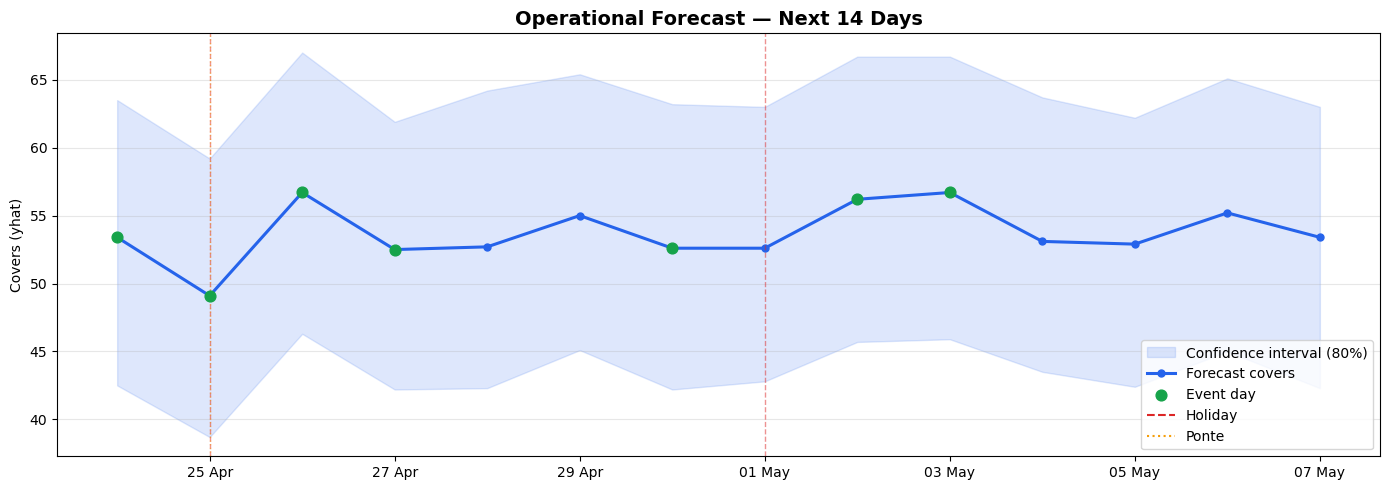

In [12]:
# ── 5. PREDICT & DISPLAY ─────────────────────────────────────────────────────
forecast_future = model.predict(future_df)

output = future_df[['ds']].copy()
output['yhat']       = forecast_future['yhat'].round(1)
output['yhat_lower'] = forecast_future['yhat_lower'].round(1)
output['yhat_upper'] = forecast_future['yhat_upper'].round(1)
output['weekday']    = output['ds'].dt.strftime('%a')
output['event_mag']  = future_df['event_magnitude'].values
output['is_holiday'] = future_df['is_holiday'].values
output['is_ponte']   = future_df['is_ponte'].values

# Reorder for readability
output = output[['ds', 'weekday', 'yhat', 'yhat_lower', 'yhat_upper',
                  'is_holiday', 'is_ponte', 'event_mag']]

print("=" * 75)
print("OPERATIONAL FORECAST — 14 days (2026-04-24 → 2026-05-07)")
print("=" * 75)
display(output)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(output['ds'], output['yhat_lower'], output['yhat_upper'],
                alpha=0.15, color='#2563eb', label='Confidence interval (80%)')
ax.plot(output['ds'], output['yhat'], color='#2563eb', linewidth=2.2,
        marker='o', markersize=5, label='Forecast covers')

# Mark holidays and ponti
for _, row in output[output['is_holiday'] == 1].iterrows():
    ax.axvline(row['ds'], color='#dc2626', linestyle='--', alpha=0.5, linewidth=1.0)
for _, row in output[output['is_ponte'] == 1].iterrows():
    ax.axvline(row['ds'], color='#f59e0b', linestyle=':', alpha=0.5, linewidth=1.0)

# Mark event days
event_days = output[output['event_mag'] > 0]
ax.scatter(event_days['ds'], event_days['yhat'], color='#16a34a',
           zorder=5, s=60, label='Event day')

from matplotlib.lines import Line2D
legend_extra = [
    Line2D([0], [0], color='#dc2626', linestyle='--', label='Holiday'),
    Line2D([0], [0], color='#f59e0b', linestyle=':', label='Ponte'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_extra)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title('Operational Forecast — Next 14 Days', fontsize=14, fontweight='bold')
ax.set_ylabel('Covers (yhat)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
